In [11]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List


In [12]:
%config InlineBackend.figure_format = 'retina'


In [19]:
# data

# Model	Setting	MTBench	Math500	GSM8K	HumanEval	LiveCodeBench	GPQA	FinanceQA
# Llama3-8B	Without Speculative Decoding	1283.62 (1)	1343.99 (1)	1231.00 (1)	1348.83 (1)	1303.98 (1)	1318.24 (1)	1083.60 (1)
# Llama3-8B	Baseline	2335.49 (2.49)	2905.37 (2.74)	1998.38 (2.28)	2867.89 (2.81)	2686.98 (2.71)	2972.41 (2.86)	1635.20 (1.85)
# Llama3-8B	SpecForge	2334.64 (2.49)	2916.42 (2.75)	2012.74 (2.32)	2898.16 (2.84)	2685.74 (2.71)	3002.29 (2.86)	1632.41 (1.83)

BENCHMARKS = ['MTBench', 'GPQA', 'FinanceQA', 'Math500', 'GSM8K', 'HumanEval', 'LCB']

throughput_data = {
    'PyTorch native kernels': [2335.49, 2972.41, 1635.20, 2905.37, 1998.38, 2867.89, 2686.98],
    'SpecForge': [2334.64, 3002.29, 1632.41, 2916.42, 2012.74, 2898.16, 2685.74],
}


In [20]:
@dataclass
class BarPlotData:
    y: List[float]
    name: str


In [23]:
def generate_bar_plot(
    data_list: List[BarPlotData],
    x_label: str,
    y_label: str,
    title: str,
    x_ticks: List[str],
    show_legend: bool = True,
    show_grid: bool = True,
    num_legend_cols: int = 2,
):
    num_bars = len(data_list[0].y)
    num_data = len(data_list)

    plt.figure(figsize=(8, 4))
    x = np.array([100, 200, 300, 400, 500, 600, 700])
    bar_width = 15

    for idx, data in enumerate(data_list):
        cur_x = x + (idx - num_data / 2) * bar_width + bar_width // 2
        plt.bar(
            x=cur_x,
            height=data.y,
            color=common.COLORS[idx],
            edgecolor='white',
            linewidth=0.5,
            alpha=0.9,
            width=bar_width,
            label=data.name,
        )

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')

    if title:
        plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)

    if x_ticks:
        plt.xticks(x, x_ticks, fontsize=common.X_TICK_FONT_SIZE, fontweight='bold')
        plt.yticks(fontsize=common.Y_TICK_FONT_SIZE, fontweight='bold')

    if show_legend:
        plt.legend(
            frameon=True,
            prop={'weight': 'bold', 'size': 14},
            loc='upper center',
            bbox_to_anchor=(0.5, -0.2),
            ncol=num_legend_cols,
        )

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()


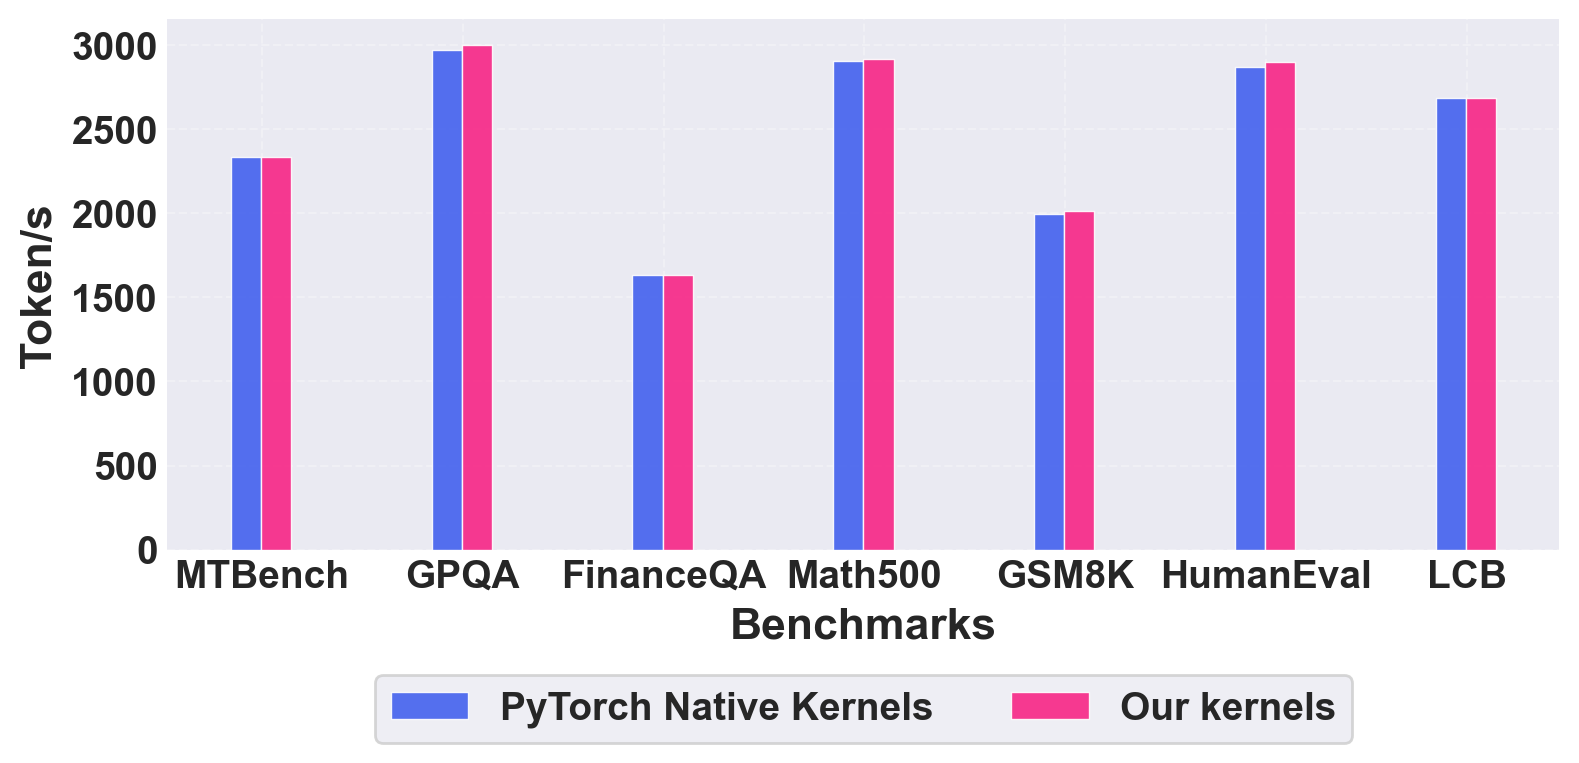

In [26]:
data_list = [
    BarPlotData(y=throughput_data['PyTorch native kernels'], name='PyTorch Native Kernels'),
    BarPlotData(y=throughput_data['SpecForge'], name='Our kernels'),
]

generate_bar_plot(
    data_list=data_list,
    x_label='Benchmarks',
    y_label='Token/s',
    title=None,
    x_ticks=BENCHMARKS,
    show_legend=True,
    show_grid=True,
    num_legend_cols=2,
)
plt.savefig("plots/plot_kernel_impact_on_inference.pdf", dpi=300)
plt.show()
